# Model Prophet – Predicció de Generació Renovable
**TFG – Gestió de Ciutats Intel·ligents i Sostenibles**  
**Arnau Ropero Garcia | UAB | Curs 2025–26**

Aquest notebook implementa el model **Prophet** de Meta per predir la generació solar i eòlica a Espanya.

- **Entrenament:** 2023–2024
- **Validació:** Gener–Març 2025
- **Test / Cas d'estudi:** Abril–Maig 2025 (inclou l'apagada del 28 d'abril)

## 0. Instal·lació de dependències

In [1]:
# Executar només si no tens prophet instal·lat
%pip install prophet

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports i configuració

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Reproducibilitat
np.random.seed(42)

# Estil gràfics
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print('Llibreries carregades correctament.')

C:\Users\Arnau\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Llibreries carregades correctament.


## 2. Càrrega i inspecció del dataset

In [5]:
PATH = r'C:\Users\Arnau\Universitat\Grau de gestió de ciutats intel·ligents i sostenibles\4rt curs\TFG\dades\dataset_final_2023-2025.csv'

df = pd.read_csv(PATH, parse_dates=['timestamp_utc'], index_col='timestamp_utc')
df.index = pd.to_datetime(df.index, utc=True).tz_convert('Europe/Madrid')

print(f'Shape: {df.shape}')
print(f'Rang temporal: {df.index.min()} → {df.index.max()}')
print(f'\nColumnes: {list(df.columns)}')
df.head()

Shape: (21000, 25)
Rang temporal: 2023-01-08 00:00:00+01:00 → 2025-05-31 23:00:00+02:00

Columnes: ['solar_MW', 'eolic_MW', 'shortwave_radiation_Wm2', 'direct_radiation_Wm2', 'diffuse_radiation_Wm2', 'cloud_cover_pct', 'wind_speed_100m_ms', 'wind_speed_10m_ms', 'wind_gusts_10m_ms', 'temperature_2m_C', 'precipitation_mm', 'hora', 'dia_setmana', 'mes', 'dia_any', 'any', 'is_cap_de_setmana', 'is_festiu', 'solar_MW_lag1h', 'eolic_MW_lag1h', 'solar_MW_lag24h', 'eolic_MW_lag24h', 'solar_MW_lag168h', 'eolic_MW_lag168h', 'split']


,solar_MW,eolic_MW,shortwave_radiation_Wm2,direct_radiation_Wm2,diffuse_radiation_Wm2,cloud_cover_pct,wind_speed_100m_ms,wind_speed_10m_ms,wind_gusts_10m_ms,temperature_2m_C,...,any,is_cap_de_setmana,is_festiu,solar_MW_lag1h,eolic_MW_lag1h,solar_MW_lag24h,eolic_MW_lag24h,solar_MW_lag168h,eolic_MW_lag168h,split
timestamp_utc,,,,,,,,,,,,,,,,,,,,,
2023-01-08 00:00:00+01:00,44.0,14999.0,0.0,0.0,0.0,98.4,7.9470,4.6315,9.735,9.94,...,2023,1,0,44.0,14909.0,20.0,7836.0,20.0,6421.0,train
2023-01-08 01:00:00+01:00,44.0,14398.0,0.0,0.0,0.0,100.0,7.8155,4.5775,9.525,9.82,...,2023,1,0,44.0,14999.0,20.0,8374.0,20.0,5747.0,train
2023-01-08 02:00:00+01:00,44.0,13923.0,0.0,0.0,0.0,100.0,7.6260,4.4140,8.660,10.14,...,2023,1,0,44.0,14398.0,20.0,8971.0,20.0,5578.0,train
2023-01-08 03:00:00+01:00,44.0,13389.0,0.0,0.0,0.0,100.0,8.2630,4.8650,8.830,10.10,...,2023,1,0,44.0,13923.0,20.0,9181.0,20.0,5400.0,train
2023-01-08 04:00:00+01:00,44.0,12555.0,0.0,0.0,0.0,100.0,7.8470,4.5310,8.955,10.20,...,2023,1,0,44.0,13389.0,20.0,9387.0,20.0,4766.0,train


In [6]:
import pandas as pd
df = pd.read_csv(PATH, parse_dates=['timestamp_utc'], index_col='timestamp_utc')

print(df[['solar_MW', 'eolic_MW']].describe().round(0))

       solar_MW  eolic_MW
count   21000.0   21000.0
mean     5027.0    6870.0
std      6119.0    4044.0
min         0.0     190.0
25%       111.0    3603.0
50%       750.0    6172.0
75%     10264.0    9509.0
max     21280.0   20718.0


In [7]:
# Comprovació valors nuls
nulls = df.isnull().sum()
print('Valors nuls per columna:')
print(nulls[nulls > 0] if nulls.sum() > 0 else 'Cap valor nul.')

# Distribució dels splits
print('\nDistribució del split:')
print(df['split'].value_counts().sort_index())

Valors nuls per columna:
Cap valor nul.

Distribució del split:
split
test           1462
train         17377
validation     2161
Name: count, dtype: int64


## 3. Divisió temporal (train / val / test)

In [8]:
train = df[df['split'] == 'train'].copy()
val   = df[df['split'] == 'validation'].copy()
test  = df[df['split'] == 'test'].copy()

print(f'Train: {train.index.min().date()} → {train.index.max().date()}  ({len(train):,} registres)')
print(f'Val:   {val.index.min().date()} → {val.index.max().date()}  ({len(val):,} registres)')
print(f'Test:  {test.index.min().date()} → {test.index.max().date()}  ({len(test):,} registres)')

Train: 2023-01-07 → 2024-12-31  (17,377 registres)
Val:   2025-01-01 → 2025-03-31  (2,161 registres)
Test:  2025-04-01 → 2025-05-31  (1,462 registres)


## 4. Funcions auxiliars

In [9]:
def calcular_metriques(y_true, y_pred, nom=''):
    """Calcula MAE, RMSE i MAPE i les retorna en un dict."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE: evitem divisió per zero
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    if nom:
        print(f'--- {nom} ---')
    print(f'  MAE : {mae:,.1f} MW')
    print(f'  RMSE: {rmse:,.1f} MW')
    print(f'  MAPE: {mape:.2f} %')
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}


def preparar_prophet(df_split, target_col):
    """Retorna el DataFrame en format Prophet (ds, y)."""
    df_p = df_split[[target_col]].reset_index()
    df_p.columns = ['ds', 'y']
    df_p['ds'] = pd.to_datetime(df_p['ds']).dt.tz_localize(None)  # Prophet no accepta timezone
    return df_p


def preparar_regressors(df_split, regressors):
    """Afegeix variables exògenes al DataFrame Prophet."""
    df_p = df_split[regressors].reset_index()
    df_p.columns = ['ds'] + regressors
    df_p['ds'] = pd.to_datetime(df_p['ds']).dt.tz_localize(None)
    return df_p


def plot_prediccions(dates, y_true, y_pred, titol, y_label='MW',
                     highlight_start=None, highlight_end=None):
    """Gràfic de predicció vs. realitat amb zona destacada opcional."""
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(dates, y_true, label='Real', color='steelblue', linewidth=1)
    ax.plot(dates, y_pred, label='Predicció Prophet', color='tomato',
            linewidth=1, linestyle='--')
    if highlight_start and highlight_end:
        ax.axvspan(pd.Timestamp(highlight_start), pd.Timestamp(highlight_end),
                   alpha=0.15, color='orange', label='Apagada 28 abr')
    ax.set_title(titol, fontweight='bold')
    ax.set_ylabel(y_label)
    ax.set_xlabel('Data')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

print('Funcions auxiliars definides.')

Funcions auxiliars definides.


---
## 5. MODEL A: Solar PV
### 5.1 Preparació de dades

In [10]:
TARGET_SOLAR = 'solar_MW'

# Regressors meteorològics rellevants per solar
REGRESSORS_SOLAR = [
    'shortwave_radiation_Wm2',
    'direct_radiation_Wm2',
    'diffuse_radiation_Wm2',
    'cloud_cover_pct',
    'temperature_2m_C',
]

# Preparar conjunts en format Prophet
train_solar = preparar_prophet(train, TARGET_SOLAR)
val_solar   = preparar_prophet(val,   TARGET_SOLAR)
test_solar  = preparar_prophet(test,  TARGET_SOLAR)

# Afegir regressors
for reg in REGRESSORS_SOLAR:
    train_solar[reg] = train[reg].values
    val_solar[reg]   = val[reg].values
    test_solar[reg]  = test[reg].values

print(f'Train solar: {len(train_solar):,} files')
train_solar.head(3)

Train solar: 17,377 files


,ds,y,shortwave_radiation_Wm2,direct_radiation_Wm2,diffuse_radiation_Wm2,cloud_cover_pct,temperature_2m_C
0,2023-01-07 23:00:00,44.0,0.0,0.0,0.0,98.4,9.94
1,2023-01-08 00:00:00,44.0,0.0,0.0,0.0,100.0,9.82
2,2023-01-08 01:00:00,44.0,0.0,0.0,0.0,100.0,10.14


### 5.2 Entrenament

In [11]:
prophet_solar = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode='multiplicative',  # adequat per solar (0 de nit)
    changepoint_prior_scale=0.05,       # regularització de canvis de tendència
    seasonality_prior_scale=10.0,
)

# Afegir regressors externs
for reg in REGRESSORS_SOLAR:
    prophet_solar.add_regressor(reg)

# Festius espanyols (millora la captura de dies festius)
prophet_solar.add_country_holidays(country_name='ES')

print('Entrenant model solar...')
prophet_solar.fit(train_solar)
print('Entrenament completat.')

Entrenant model solar...


21:41:33 - cmdstanpy - INFO - Chain [1] start processing
21:41:53 - cmdstanpy - INFO - Chain [1] done processing


Entrenament completat.


### 5.3 Predicció i avaluació – Validació

In [12]:
# Predicció sobre validació
pred_val_solar = prophet_solar.predict(val_solar)

y_true_val_solar = val_solar['y'].values
y_pred_val_solar = pred_val_solar['yhat'].values

# Clip: no pot haver generació negativa
y_pred_val_solar = np.clip(y_pred_val_solar, 0, None)

metriques_val_solar = calcular_metriques(y_true_val_solar, y_pred_val_solar, 'SOLAR – Validació')

--- SOLAR – Validació ---
  MAE : 1,345.6 MW
  RMSE: 2,142.9 MW
  MAPE: 329.14 %


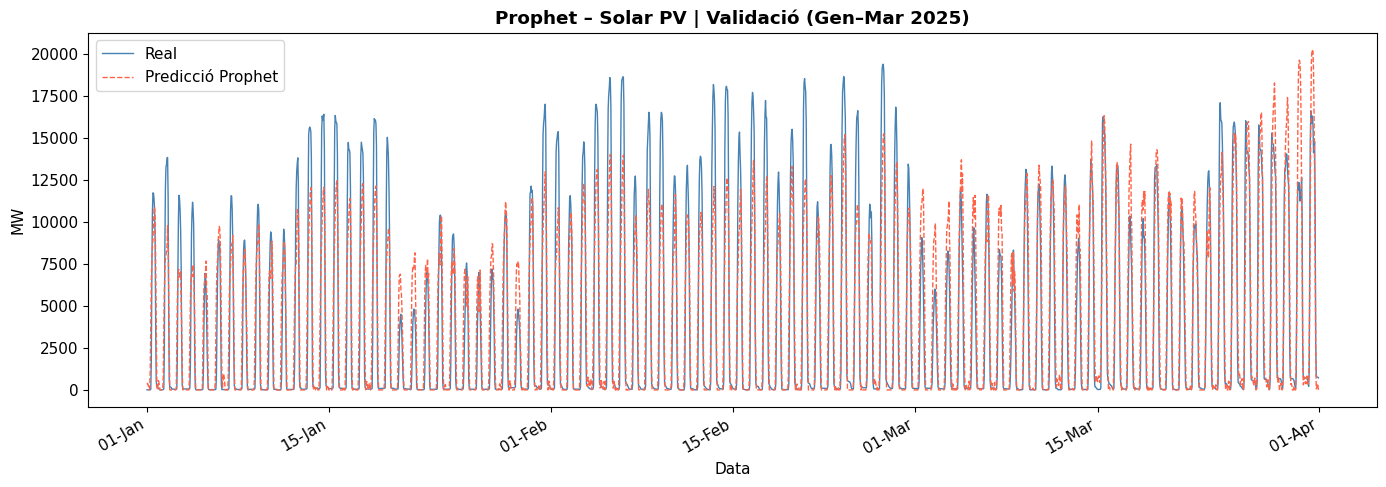

In [14]:
plot_prediccions(
    dates=val_solar['ds'],
    y_true=y_true_val_solar,
    y_pred=y_pred_val_solar,
    titol='Prophet – Solar PV | Validació (Gen–Mar 2025)'
)

### 5.4 Predicció i avaluació – Test (amb apagada)

In [15]:
# Predicció sobre test
pred_test_solar = prophet_solar.predict(test_solar)

y_true_test_solar = test_solar['y'].values
y_pred_test_solar = np.clip(pred_test_solar['yhat'].values, 0, None)

metriques_test_solar = calcular_metriques(y_true_test_solar, y_pred_test_solar, 'SOLAR – Test')

--- SOLAR – Test ---
  MAE : 2,059.9 MW
  RMSE: 3,063.5 MW
  MAPE: 220.36 %


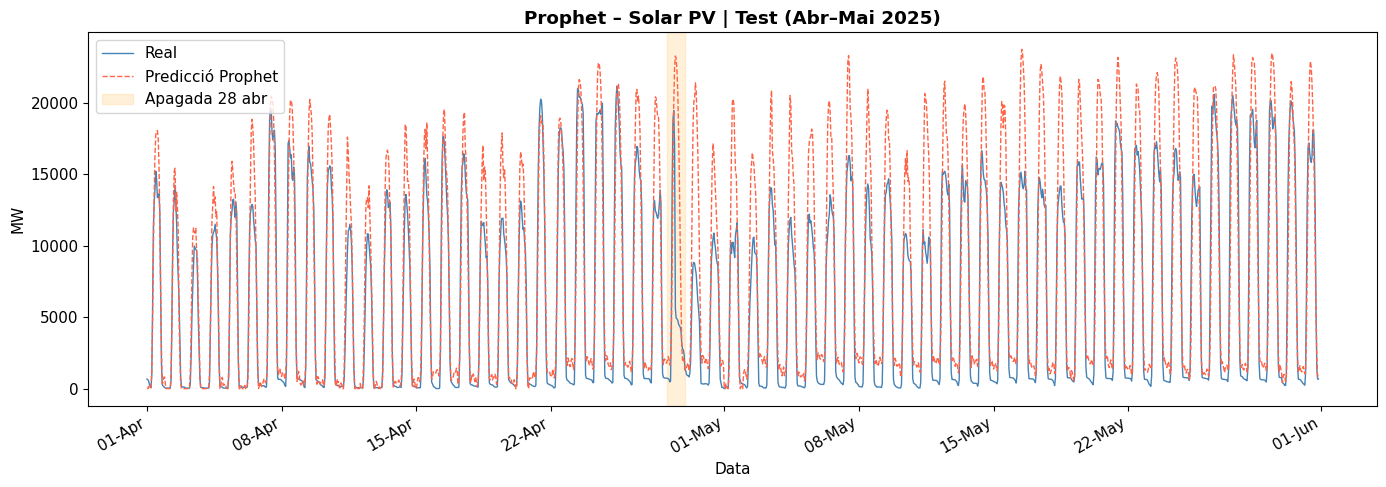

In [16]:
plot_prediccions(
    dates=test_solar['ds'],
    y_true=y_true_test_solar,
    y_pred=y_pred_test_solar,
    titol='Prophet – Solar PV | Test (Abr–Mai 2025)',
    highlight_start='2025-04-28 00:00',
    highlight_end='2025-04-28 23:00'
)

### 5.5 Detecció d'anomalies – 28 d'abril 2025

In [17]:
# Construir DataFrame d'anàlisi d'anomalies per al període test
anomaly_solar = pd.DataFrame({
    'ds':     test_solar['ds'].values,
    'y_real': y_true_test_solar,
    'y_pred': y_pred_test_solar,
    'error':  y_true_test_solar - y_pred_test_solar,
})
anomaly_solar['abs_error'] = anomaly_solar['error'].abs()

# Umbral: mu + 2*sigma sobre les dades de validació
threshold_solar = (
    np.abs(y_true_val_solar - y_pred_val_solar).mean() +
    2 * np.abs(y_true_val_solar - y_pred_val_solar).std()
)
print(f'Llindar d\'anomalia solar (μ + 2σ val): {threshold_solar:,.0f} MW')

anomaly_solar['anomalia'] = anomaly_solar['abs_error'] > threshold_solar

# Focus en l'apagada
apagada = anomaly_solar[
    (anomaly_solar['ds'] >= '2025-04-28') &
    (anomaly_solar['ds'] < '2025-04-29')
].copy()

print(f'\nHores del 28 abr amb anomalia detectada: {apagada["anomalia"].sum()} / {len(apagada)}')
print(f'Error màxim: {apagada["abs_error"].max():,.0f} MW')
print(f'Error mitjà (28 abr): {apagada["abs_error"].mean():,.0f} MW')
apagada[['ds','y_real','y_pred','error','anomalia']].to_string(index=False)

Llindar d'anomalia solar (μ + 2σ val): 4,681 MW

Hores del 28 abr amb anomalia detectada: 9 / 24
Error màxim: 18,171 MW
Error mitjà (28 abr): 5,307 MW


'                 ds  y_real       y_pred         error  anomalia\n2025-04-28 00:00:00   732.0  1773.975006  -1041.975006     False\n2025-04-28 01:00:00   723.0  2012.690202  -1289.690202     False\n2025-04-28 02:00:00   701.0  2237.003052  -1536.003052     False\n2025-04-28 03:00:00   659.0  2050.005649  -1391.005649     False\n2025-04-28 04:00:00   464.0  1666.166058  -1202.166058     False\n2025-04-28 05:00:00   531.0  2031.379435  -1500.379435     False\n2025-04-28 06:00:00  4884.0  3864.267931   1019.732069     False\n2025-04-28 07:00:00 14135.0  8856.588898   5278.411102      True\n2025-04-28 08:00:00 18800.0 15048.923586   3751.076414     False\n2025-04-28 09:00:00 19459.0 19943.600012   -484.600012     False\n2025-04-28 10:00:00 17016.0 22502.338723  -5486.338723      True\n2025-04-28 11:00:00  5601.0 23276.371570 -17675.371570      True\n2025-04-28 12:00:00  4932.0 23102.868735 -18170.868735      True\n2025-04-28 13:00:00  4880.0 22239.038416 -17359.038416      True\n2025-04-2

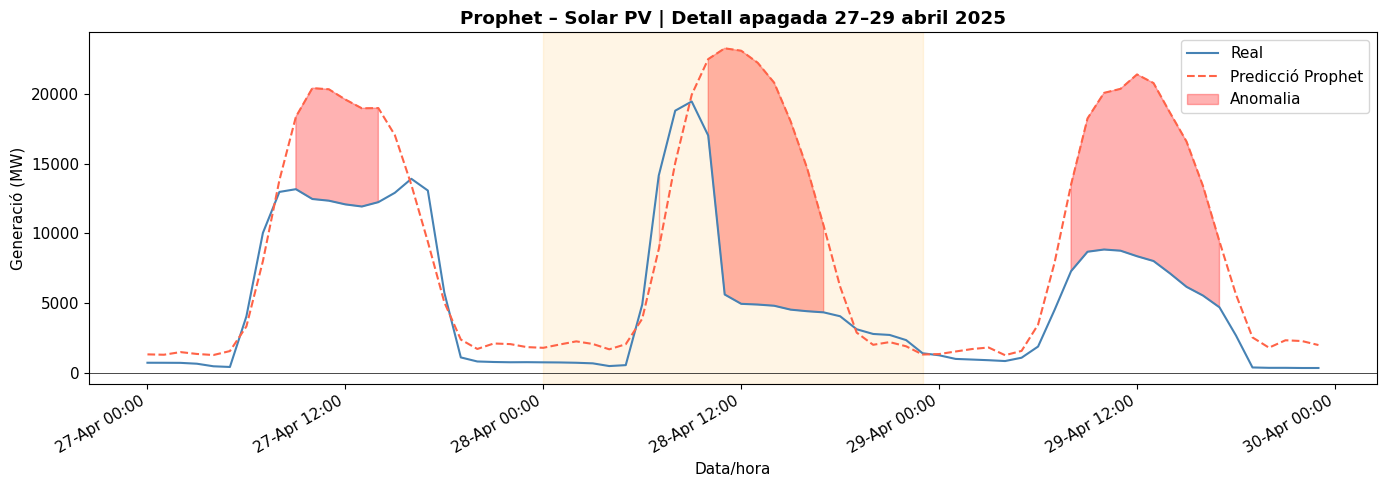

In [18]:
# Gràfic detall 27–29 abril (context de l'apagada)
mask_apagada = (anomaly_solar['ds'] >= '2025-04-27') & (anomaly_solar['ds'] <= '2025-04-29 23:00')
sub = anomaly_solar[mask_apagada]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sub['ds'], sub['y_real'], label='Real', color='steelblue', linewidth=1.5)
ax.plot(sub['ds'], sub['y_pred'], label='Predicció Prophet', color='tomato',
        linewidth=1.5, linestyle='--')
ax.fill_between(sub['ds'], sub['y_real'], sub['y_pred'],
                where=sub['anomalia'], alpha=0.3, color='red', label='Anomalia')
ax.axvspan(pd.Timestamp('2025-04-28 00:00'), pd.Timestamp('2025-04-28 23:00'),
           alpha=0.1, color='orange')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Prophet – Solar PV | Detall apagada 27–29 abril 2025', fontweight='bold')
ax.set_ylabel('Generació (MW)')
ax.set_xlabel('Data/hora')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %H:%M'))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('prophet_solar_detall_apagada.pdf', bbox_inches='tight')
plt.show()

### 5.6 Components de la predicció (interpretabilitat)

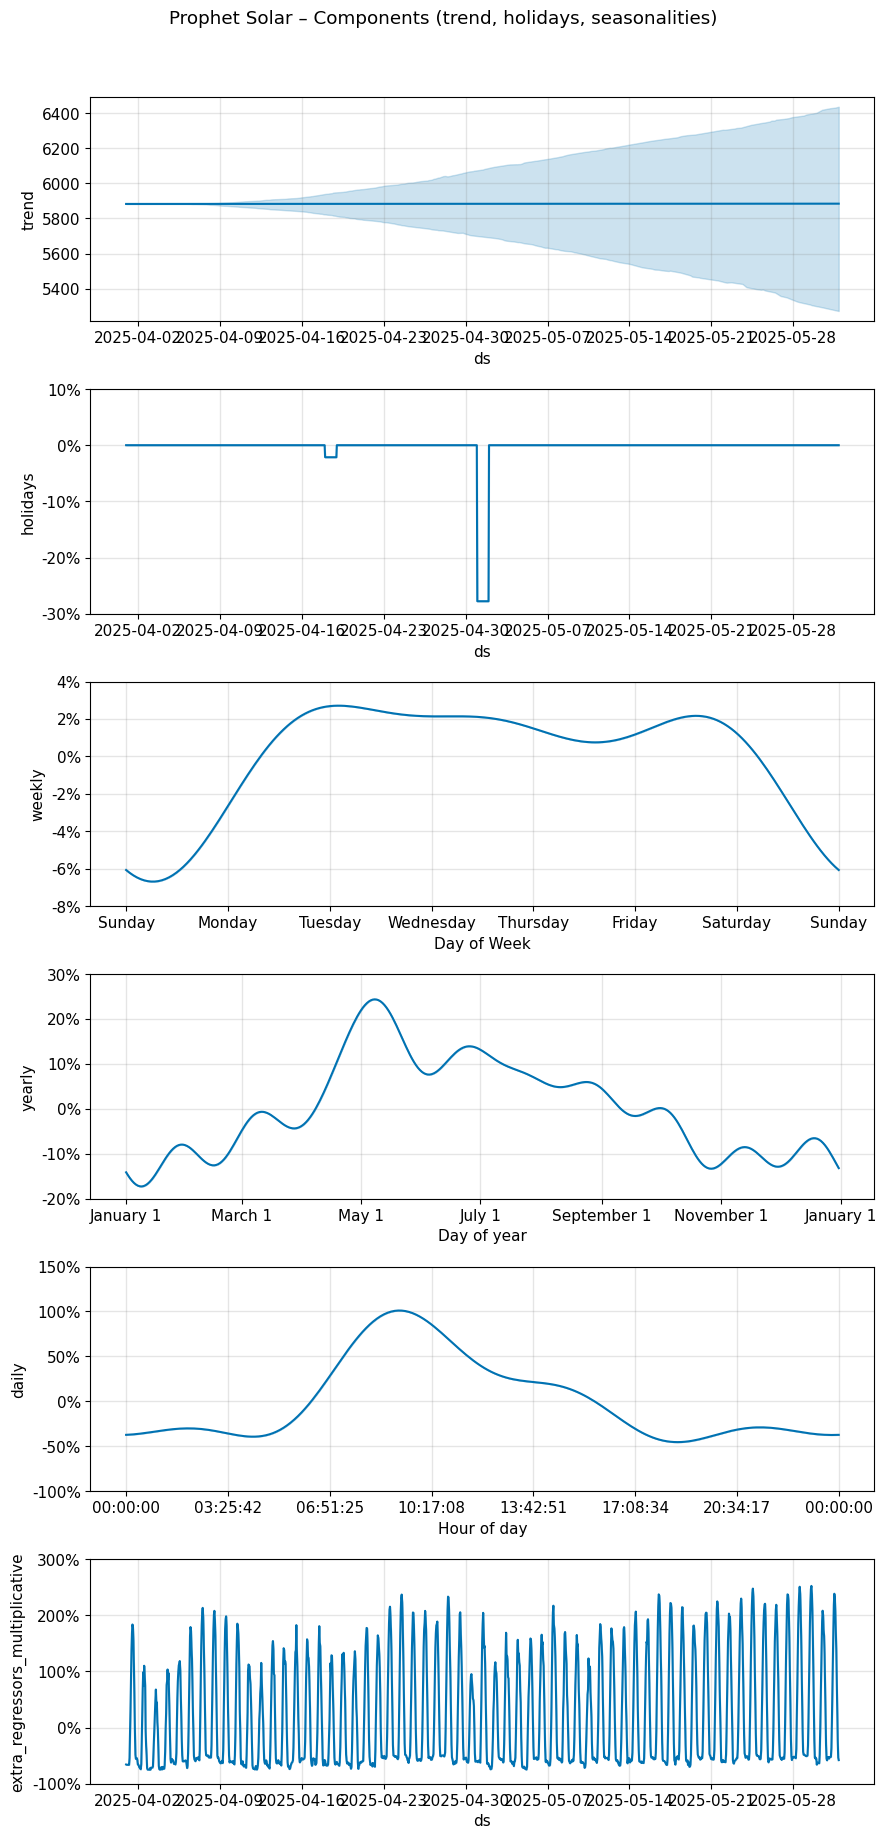

In [19]:
fig = prophet_solar.plot_components(pred_test_solar)
fig.suptitle('Prophet Solar – Components (trend, holidays, seasonalities)', y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# Quants registres nocturns hi ha a validació?
print(val[val['solar_MW'] == 0].shape[0], 'hores amb solar = 0')
print(val[val['solar_MW'] > 0].shape[0], 'hores amb solar > 0')

0 hores amb solar = 0
2161 hores amb solar > 0


In [21]:
# Recalcular MAPE solar només hores diürnes (solar_MW > 50 MW com a llindar)
mask_dia = val['solar_MW'] > 50
y_true_dia = val.loc[mask_dia, 'solar_MW'].values
y_pred_dia = y_pred_val_solar[val.index.isin(val[mask_dia].index)]

mape_dia = np.mean(np.abs((y_true_dia - y_pred_dia) / y_true_dia)) * 100
print(f'MAPE solar (només diürn): {mape_dia:.2f} %')

MAPE solar (només diürn): 197.96 %


In [22]:
print(val['solar_MW'].describe())
print(f'\nValors < 100 MW: {(val["solar_MW"] < 100).sum()}')
print(f'Valors < 500 MW: {(val["solar_MW"] < 500).sum()}')

# Veure les primeres files
print(val[['solar_MW']].head(10))

count     2161.000000
mean      4004.145766
std       5508.083690
min          4.000000
25%         53.000000
50%        299.000000
75%       8129.000000
max      19387.000000
Name: solar_MW, dtype: float64

Valors < 100 MW: 842
Valors < 500 MW: 1158
                           solar_MW
timestamp_utc                      
2025-01-01 00:00:00+00:00       4.0
2025-01-01 01:00:00+00:00       4.0
2025-01-01 02:00:00+00:00       4.0
2025-01-01 03:00:00+00:00       4.0
2025-01-01 04:00:00+00:00       4.0
2025-01-01 05:00:00+00:00       4.0
2025-01-01 06:00:00+00:00       4.0
2025-01-01 07:00:00+00:00      42.0
2025-01-01 08:00:00+00:00    1786.0
2025-01-01 09:00:00+00:00    7078.0


---
## 6. MODEL B: Eòlica
### 6.1 Preparació de dades

In [23]:
TARGET_EOLIC = 'eolic_MW'

# Regressors meteorològics rellevants per eòlica
REGRESSORS_EOLIC = [
    'wind_speed_100m_ms',
    'wind_speed_10m_ms',
    'wind_gusts_10m_ms',
    'temperature_2m_C',
    'precipitation_mm',
]

train_eolic = preparar_prophet(train, TARGET_EOLIC)
val_eolic   = preparar_prophet(val,   TARGET_EOLIC)
test_eolic  = preparar_prophet(test,  TARGET_EOLIC)

for reg in REGRESSORS_EOLIC:
    train_eolic[reg] = train[reg].values
    val_eolic[reg]   = val[reg].values
    test_eolic[reg]  = test[reg].values

print(f'Train eòlica: {len(train_eolic):,} files')
train_eolic.head(3)

Train eòlica: 17,377 files


,ds,y,wind_speed_100m_ms,wind_speed_10m_ms,wind_gusts_10m_ms,temperature_2m_C,precipitation_mm
0,2023-01-07 23:00:00,14999.0,7.9470,4.6315,9.735,9.94,0.52
1,2023-01-08 00:00:00,14398.0,7.8155,4.5775,9.525,9.82,0.52
2,2023-01-08 01:00:00,13923.0,7.6260,4.4140,8.660,10.14,0.70


### 6.2 Entrenament

In [24]:
prophet_eolic = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode='additive',  # eòlica no té el patró nit=0 de solar
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0,
)

for reg in REGRESSORS_EOLIC:
    prophet_eolic.add_regressor(reg)

prophet_eolic.add_country_holidays(country_name='ES')

print('Entrenant model eòlic...')
prophet_eolic.fit(train_eolic)
print('Entrenament completat.')

Entrenant model eòlic...


21:44:43 - cmdstanpy - INFO - Chain [1] start processing
21:44:53 - cmdstanpy - INFO - Chain [1] done processing


Entrenament completat.


### 6.3 Predicció i avaluació – Validació

In [25]:
pred_val_eolic = prophet_eolic.predict(val_eolic)

y_true_val_eolic = val_eolic['y'].values
y_pred_val_eolic = np.clip(pred_val_eolic['yhat'].values, 0, None)

metriques_val_eolic = calcular_metriques(y_true_val_eolic, y_pred_val_eolic, 'EÒLICA – Validació')

--- EÒLICA – Validació ---
  MAE : 1,912.6 MW
  RMSE: 2,455.9 MW
  MAPE: 30.76 %


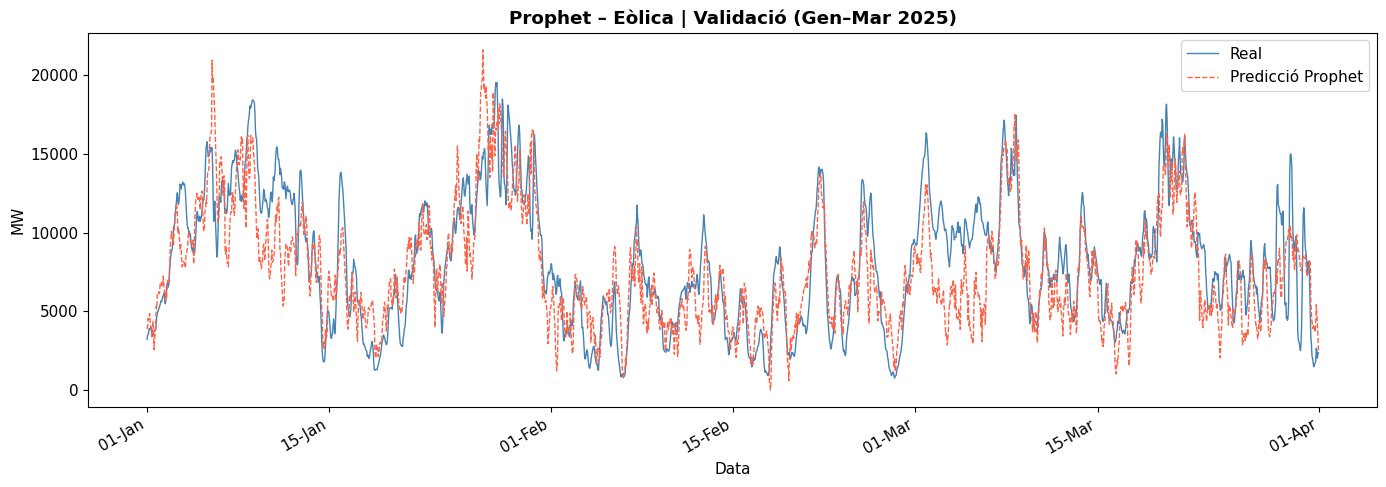

In [26]:
plot_prediccions(
    dates=val_eolic['ds'],
    y_true=y_true_val_eolic,
    y_pred=y_pred_val_eolic,
    titol='Prophet – Eòlica | Validació (Gen–Mar 2025)'
)

### 6.4 Predicció i avaluació – Test (amb apagada)

In [27]:
pred_test_eolic = prophet_eolic.predict(test_eolic)

y_true_test_eolic = test_eolic['y'].values
y_pred_test_eolic = np.clip(pred_test_eolic['yhat'].values, 0, None)

metriques_test_eolic = calcular_metriques(y_true_test_eolic, y_pred_test_eolic, 'EÒLICA – Test')

--- EÒLICA – Test ---
  MAE : 1,710.6 MW
  RMSE: 2,199.2 MW
  MAPE: 42.50 %


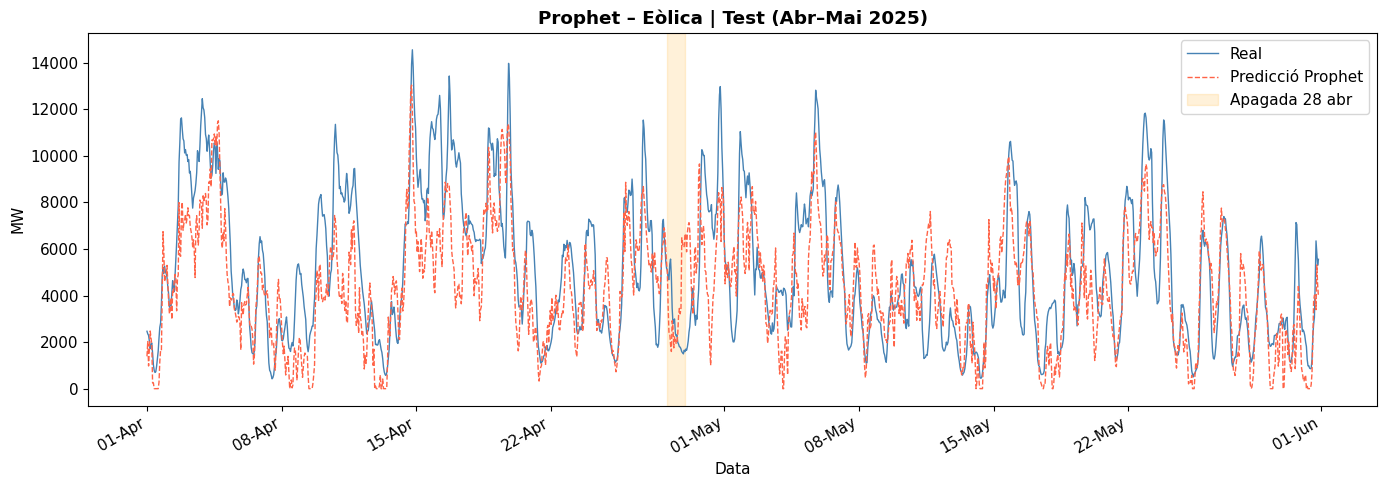

In [28]:
plot_prediccions(
    dates=test_eolic['ds'],
    y_true=y_true_test_eolic,
    y_pred=y_pred_test_eolic,
    titol='Prophet – Eòlica | Test (Abr–Mai 2025)',
    highlight_start='2025-04-28 00:00',
    highlight_end='2025-04-28 23:00'
)

### 6.5 Detecció d'anomalies – 28 d'abril 2025

In [29]:
anomaly_eolic = pd.DataFrame({
    'ds':     test_eolic['ds'].values,
    'y_real': y_true_test_eolic,
    'y_pred': y_pred_test_eolic,
    'error':  y_true_test_eolic - y_pred_test_eolic,
})
anomaly_eolic['abs_error'] = anomaly_eolic['error'].abs()

threshold_eolic = (
    np.abs(y_true_val_eolic - y_pred_val_eolic).mean() +
    2 * np.abs(y_true_val_eolic - y_pred_val_eolic).std()
)
print(f'Llindar d\'anomalia eòlica (μ + 2σ val): {threshold_eolic:,.0f} MW')

anomaly_eolic['anomalia'] = anomaly_eolic['abs_error'] > threshold_eolic

apagada_e = anomaly_eolic[
    (anomaly_eolic['ds'] >= '2025-04-28') &
    (anomaly_eolic['ds'] < '2025-04-29')
]
print(f'\nHores del 28 abr amb anomalia eòlica detectada: {apagada_e["anomalia"].sum()} / {len(apagada_e)}')
print(f'Error màxim: {apagada_e["abs_error"].max():,.0f} MW')

Llindar d'anomalia eòlica (μ + 2σ val): 4,994 MW

Hores del 28 abr amb anomalia eòlica detectada: 1 / 24
Error màxim: 5,059 MW


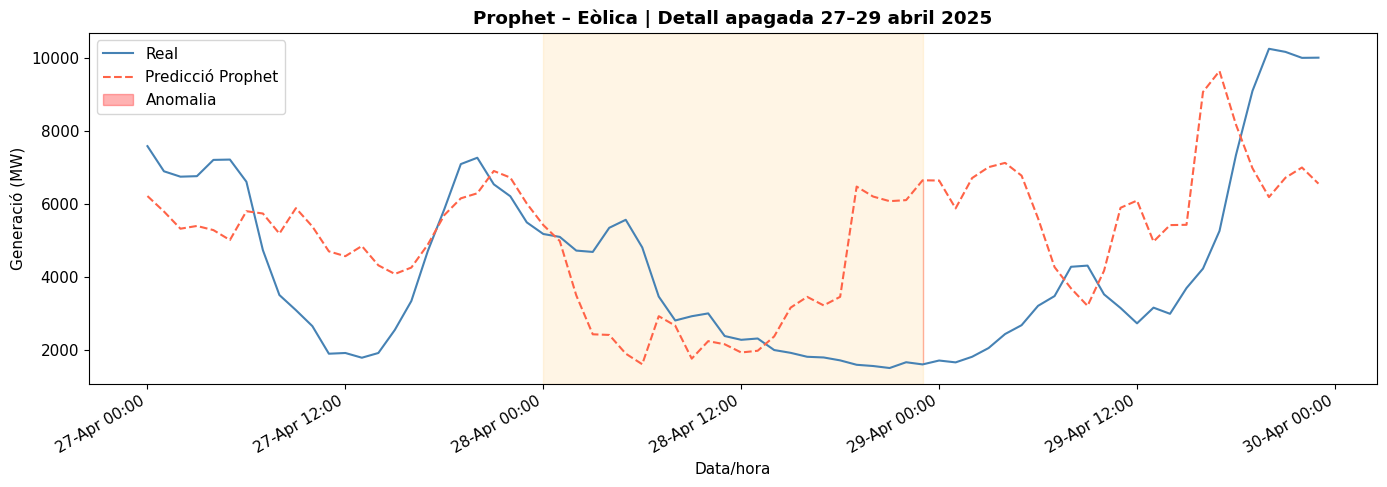

In [30]:
# Gràfic detall apagada – eòlica
mask_apagada_e = (anomaly_eolic['ds'] >= '2025-04-27') & (anomaly_eolic['ds'] <= '2025-04-29 23:00')
sub_e = anomaly_eolic[mask_apagada_e]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sub_e['ds'], sub_e['y_real'], label='Real', color='steelblue', linewidth=1.5)
ax.plot(sub_e['ds'], sub_e['y_pred'], label='Predicció Prophet', color='tomato',
        linewidth=1.5, linestyle='--')
ax.fill_between(sub_e['ds'], sub_e['y_real'], sub_e['y_pred'],
                where=sub_e['anomalia'], alpha=0.3, color='red', label='Anomalia')
ax.axvspan(pd.Timestamp('2025-04-28 00:00'), pd.Timestamp('2025-04-28 23:00'),
           alpha=0.1, color='orange')
ax.set_title('Prophet – Eòlica | Detall apagada 27–29 abril 2025', fontweight='bold')
ax.set_ylabel('Generació (MW)')
ax.set_xlabel('Data/hora')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %H:%M'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

---
## 7. Resum de mètriques

In [31]:
resum = pd.DataFrame({
    'Model / Conjunt': [
        'Prophet Solar – Validació',
        'Prophet Solar – Test',
        'Prophet Eòlica – Validació',
        'Prophet Eòlica – Test',
    ],
    'MAE (MW)':  [
        round(metriques_val_solar['MAE'], 1),
        round(metriques_test_solar['MAE'], 1),
        round(metriques_val_eolic['MAE'], 1),
        round(metriques_test_eolic['MAE'], 1),
    ],
    'RMSE (MW)': [
        round(metriques_val_solar['RMSE'], 1),
        round(metriques_test_solar['RMSE'], 1),
        round(metriques_val_eolic['RMSE'], 1),
        round(metriques_test_eolic['RMSE'], 1),
    ],
    'MAPE (%)':  [
        round(metriques_val_solar['MAPE'], 2),
        round(metriques_test_solar['MAPE'], 2),
        round(metriques_val_eolic['MAPE'], 2),
        round(metriques_test_eolic['MAPE'], 2),
    ],
})

print('\n=== RESUM MÈTRIQUES PROPHET ===')
print(resum.to_string(index=False))

# Desar CSV per usar als altres notebooks
resum.to_csv('metriques_prophet.csv', index=False)
print('\nDades desades a metriques_prophet.csv')


=== RESUM MÈTRIQUES PROPHET ===
           Model / Conjunt  MAE (MW)  RMSE (MW)  MAPE (%)
 Prophet Solar – Validació    1345.6     2142.9    329.14
      Prophet Solar – Test    2059.9     3063.5    220.36
Prophet Eòlica – Validació    1912.6     2455.9     30.76
     Prophet Eòlica – Test    1710.6     2199.2     42.50

Dades desades a metriques_prophet.csv


### Interpretació dels resultats

El model Prophet incorpora:
- **Estacionalitat diària, setmanal i anual** per capturar el patró horari solar (0 de nit, pic al migdia) i la variació estacional.
- **Regressors externs** (irradiació, vent, temperatura) que milloren la precisió respecte a un model univariat pur.
- **Festius espanyols** via `add_country_holidays`.

L'anomalia del **28 d'abril 2025** es manifesta com un error negatiu elevat: el model prediu una generació solar d'acord amb les condicions meteorològiques favorables (irradiació alta, baixa nuvolositat), però la generació real cau dràsticament. Aquesta divergència no és meteorològicament explicable → signatura de l'apagada.

---
## 8. Desar models (opcional)

In [32]:
import json
from prophet.serialize import model_to_json, model_from_json

with open('prophet_solar.json', 'w') as f:
    json.dump(model_to_json(prophet_solar), f)

with open('prophet_eolic.json', 'w') as f:
    json.dump(model_to_json(prophet_eolic), f)

print('Models desats com prophet_solar.json i prophet_eolic.json')

Models desats com prophet_solar.json i prophet_eolic.json


In [33]:
print('=== BASELINE NAÏF (persistència) ===')

# Solar
y_naive_val_solar  = val['solar_MW_lag1h'].values
y_naive_test_solar = test['solar_MW_lag1h'].values

naive_val_solar  = calcular_metriques(y_true_val_solar,  y_naive_val_solar,  'SOLAR Naïf – Validació')
naive_test_solar = calcular_metriques(y_true_test_solar, y_naive_test_solar, 'SOLAR Naïf – Test')

# Eòlica
y_naive_val_eolic  = val['eolic_MW_lag1h'].values
y_naive_test_eolic = test['eolic_MW_lag1h'].values

naive_val_eolic  = calcular_metriques(y_true_val_eolic,  y_naive_val_eolic,  'EÒLICA Naïf – Validació')
naive_test_eolic = calcular_metriques(y_true_test_eolic, y_naive_test_eolic, 'EÒLICA Naïf – Test')

=== BASELINE NAÏF (persistència) ===
--- SOLAR Naïf – Validació ---
  MAE : 1,071.0 MW
  RMSE: 2,025.3 MW
  MAPE: 68.57 %
--- SOLAR Naïf – Test ---
  MAE : 1,297.3 MW
  RMSE: 2,332.0 MW
  MAPE: 46.57 %
--- EÒLICA Naïf – Validació ---
  MAE : 405.9 MW
  RMSE: 576.1 MW
  MAPE: 5.98 %
--- EÒLICA Naïf – Test ---
  MAE : 443.2 MW
  RMSE: 622.1 MW
  MAPE: 10.74 %
